In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
df = pd.read_csv("OTT_Show_Dataset.csv")
df.head()

,Show_ID,Genre,Language,Runtime,Release_Year,Budget,Rating,Viewership
0,OTT00001,Drama,Hindi,36,2021,9.2,7.3,7.57
1,OTT00002,Thriller,Hindi,65,2022,12.6,7.9,8.13
2,OTT00003,Crime,Hindi,56,2019,4.0,5.9,4.58
3,OTT00004,Drama,Hindi,72,2021,53.9,6.3,25.70
4,OTT00005,Thriller,Korean,68,2020,17.3,8.6,8.21


In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Rows: 5000
Columns: 8

Column names:
['Show_ID', 'Genre', 'Language', 'Runtime', 'Release_Year', 'Budget', 'Rating', 'Viewership']

Data types:
Show_ID          object
Genre            object
Language         object
Runtime           int64
Release_Year      int64
Budget          float64
Rating          float64
Viewership      float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Show_ID       5000 non-null   object 
 1   Genre         5000 non-null   object 
 2   Language      5000 non-null   object 
 3   Runtime       5000 non-null   int64  
 4   Release_Year  5000 non-null   int64  
 5   Budget        5000 non-null   float64
 6   Rating        5000 non-null   float64
 7   Viewership    5000 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 312.6+ KB


In [17]:
df.isnull().sum()

,0
Show_ID,0
Genre,0
Language,0
Runtime,0
Release_Year,0
Budget,0
Rating,0
Viewership,0


In [18]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate Show IDs:",
    df["Show_ID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Show IDs: 0


In [19]:
df.describe()

,Runtime,Release_Year,Budget,Rating,Viewership
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,52.550600,2022.060600,21.456020,7.212480,10.758126
std,15.594604,2.570729,13.636497,0.907882,5.194826
min,20.000000,2018.000000,4.000000,4.000000,1.000000
25%,42.000000,2020.000000,12.000000,6.600000,7.090000
50%,52.000000,2022.000000,17.800000,7.200000,9.820000
75%,63.000000,2024.000000,27.100000,7.800000,13.112500
max,109.000000,2026.000000,100.000000,9.800000,56.510000


In [20]:
print("Genres:")
print(df["Genre"].value_counts())

print("\nLanguages:")
print(df["Language"].value_counts())

Genres:
Genre
Drama          1057
Comedy          784
Action          762
Thriller        718
Romance         599
Crime           480
Sci-Fi          354
Documentary     246
Name: count, dtype: int64

Languages:
Language
English      1510
Hindi        1082
Tamil         783
Telugu        537
Korean        466
Spanish       379
Malayalam     243
Name: count, dtype: int64


In [21]:
print("Invalid Runtime:", (df["Runtime"] <= 0).sum())

print("Invalid Budget:", (df["Budget"] <= 0).sum())

print("Invalid Rating:", ((df["Rating"] < 0) | (df["Rating"] > 10)).sum())

print(
    "Invalid Release Year:",
    ((df["Release_Year"] < 1900) | (df["Release_Year"] > 2026)).sum()
)

print("Invalid Viewership:", (df["Viewership"] < 0).sum())

Invalid Runtime: 0
Invalid Budget: 0
Invalid Rating: 0
Invalid Release Year: 0
Invalid Viewership: 0


In [22]:
genre_counts = df["Genre"].value_counts()

print(genre_counts)

Genre
Drama          1057
Comedy          784
Action          762
Thriller        718
Romance         599
Crime           480
Sci-Fi          354
Documentary     246
Name: count, dtype: int64


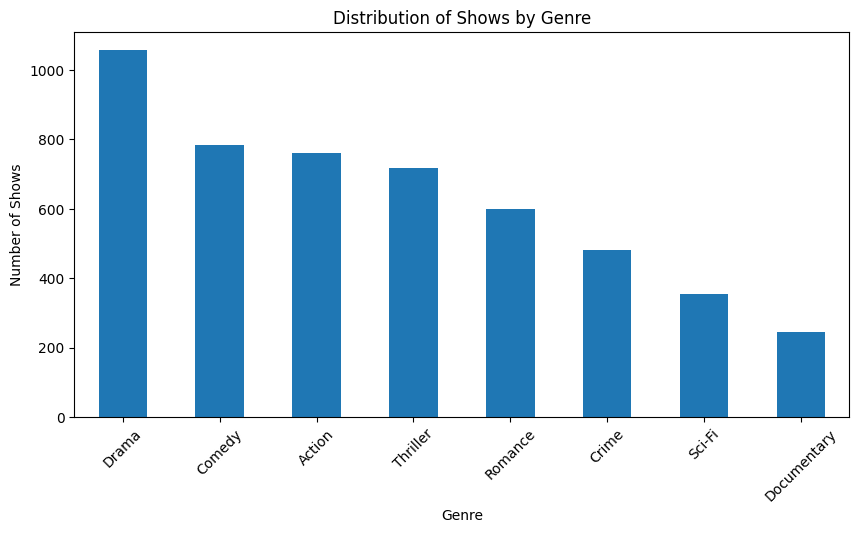

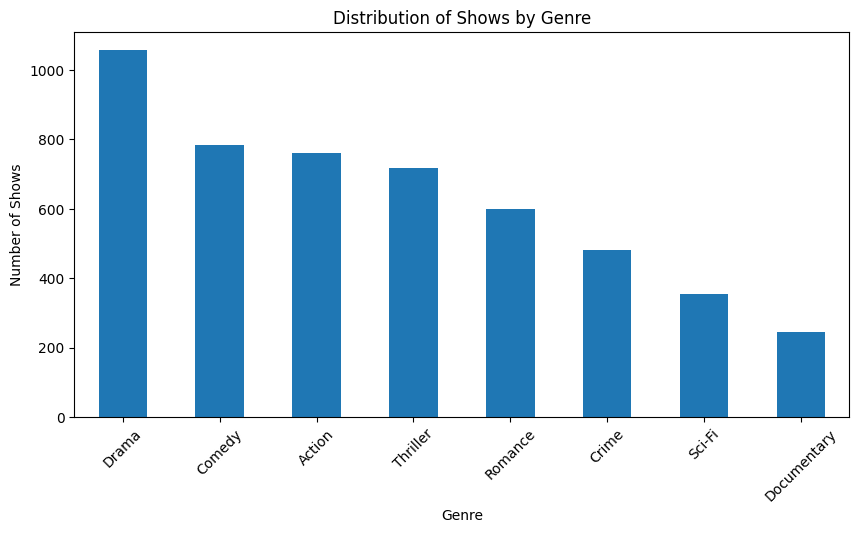

In [23]:
plt.figure(figsize=(10, 5))

genre_counts.plot(kind="bar")

plt.title("Distribution of Shows by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(10, 5))

genre_counts.plot(kind="bar")

plt.title("Distribution of Shows by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)

plt.show()

In [24]:
genre_analysis = df.groupby("Genre").agg(
    Number_of_Shows=("Show_ID", "count"),
    Average_Viewership=("Viewership", "mean"),
    Average_Rating=("Rating", "mean"),
    Average_Budget=("Budget", "mean")
).round(2)

genre_analysis.sort_values("Average_Viewership", ascending=False)

,Number_of_Shows,Average_Viewership,Average_Rating,Average_Budget
Genre,,,,
Action,762,12.22,7.20,21.52
Thriller,718,11.39,7.19,21.65
Sci-Fi,354,11.11,7.21,21.14
Crime,480,10.98,7.18,21.91
Drama,1057,10.66,7.24,21.07
Romance,599,10.51,7.23,22.92
Comedy,784,9.79,7.21,21.08
Documentary,246,7.58,7.23,19.57


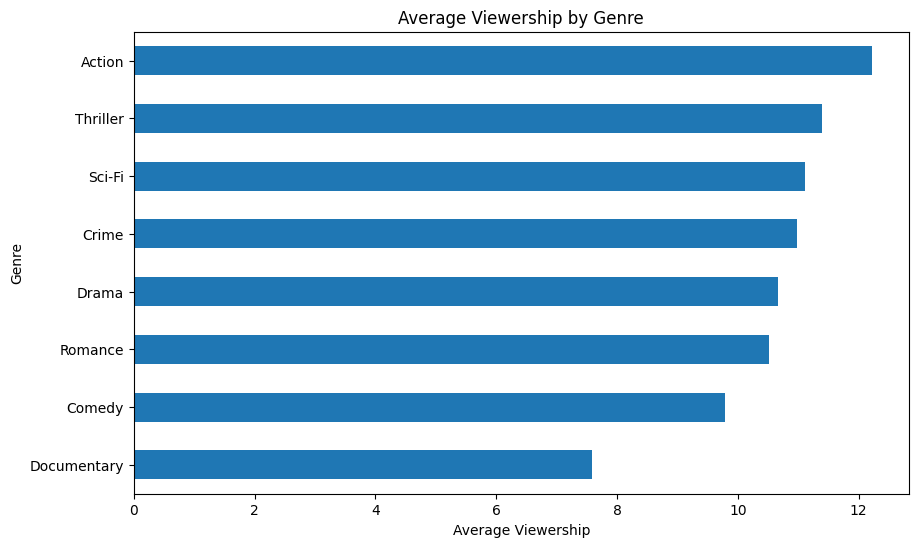

In [25]:
genre_analysis["Average_Viewership"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Average Viewership by Genre"
)

plt.xlabel("Average Viewership")
plt.ylabel("Genre")
plt.show()

In [26]:
language_analysis = df.groupby("Language").agg(
    Number_of_Shows=("Show_ID", "count"),
    Average_Viewership=("Viewership", "mean"),
    Average_Rating=("Rating", "mean"),
    Average_Budget=("Budget", "mean")
).round(2)

language_analysis.sort_values("Average_Viewership", ascending=False)

,Number_of_Shows,Average_Viewership,Average_Rating,Average_Budget
Language,,,,
English,1510,11.66,7.25,21.37
Hindi,1082,11.29,7.17,21.11
Korean,466,11.16,7.18,23.05
Spanish,379,10.00,7.22,21.38
Tamil,783,9.90,7.20,21.17
Telugu,537,9.59,7.23,21.40
Malayalam,243,8.50,7.23,21.64


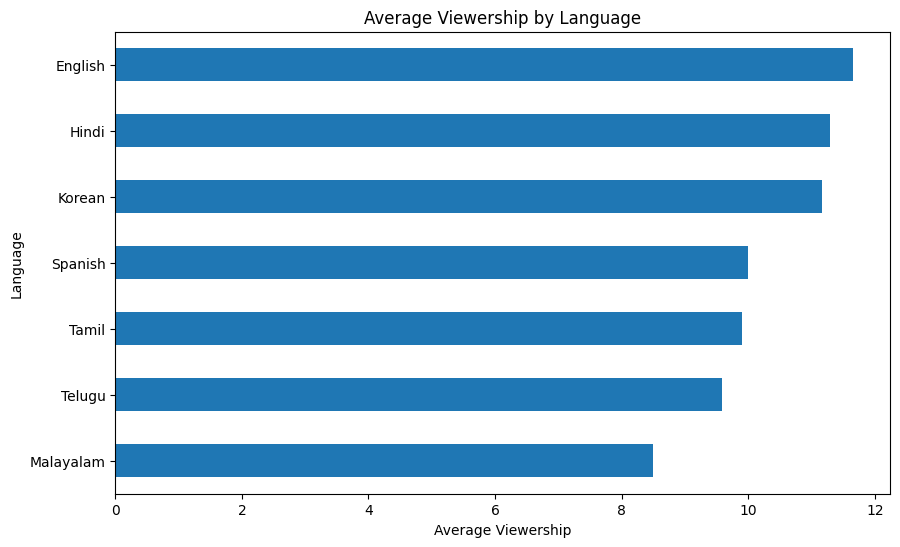

In [27]:
language_analysis["Average_Viewership"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Average Viewership by Language"
)

plt.xlabel("Average Viewership")
plt.ylabel("Language")
plt.show()

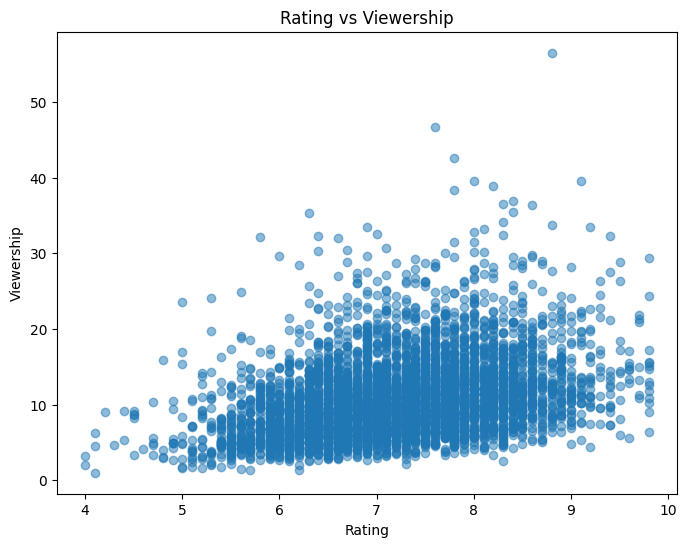

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(df["Rating"], df["Viewership"], alpha=0.5)

plt.xlabel("Rating")
plt.ylabel("Viewership")
plt.title("Rating vs Viewership")

plt.show()

In [29]:
correlation = df["Rating"].corr(df["Viewership"])

print("Rating vs Viewership Correlation:", round(correlation, 3))

Rating vs Viewership Correlation: 0.351


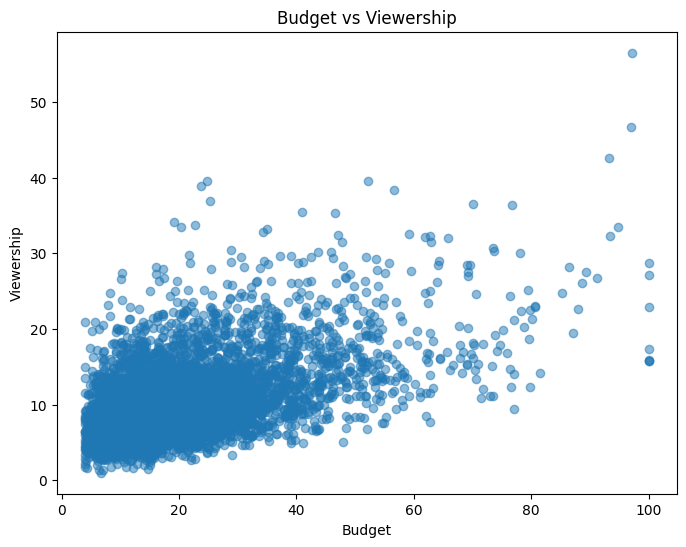

Budget vs Viewership Correlation: 0.51


In [30]:
plt.figure(figsize=(8,6))

plt.scatter(df["Budget"], df["Viewership"], alpha=0.5)

plt.xlabel("Budget")
plt.ylabel("Viewership")
plt.title("Budget vs Viewership")

plt.show()

print(
    "Budget vs Viewership Correlation:",
    round(df["Budget"].corr(df["Viewership"]), 3)
)

In [31]:
print(
    "Runtime vs Viewership Correlation:",
    round(df["Runtime"].corr(df["Viewership"]), 3)
)

Runtime vs Viewership Correlation: 0.07


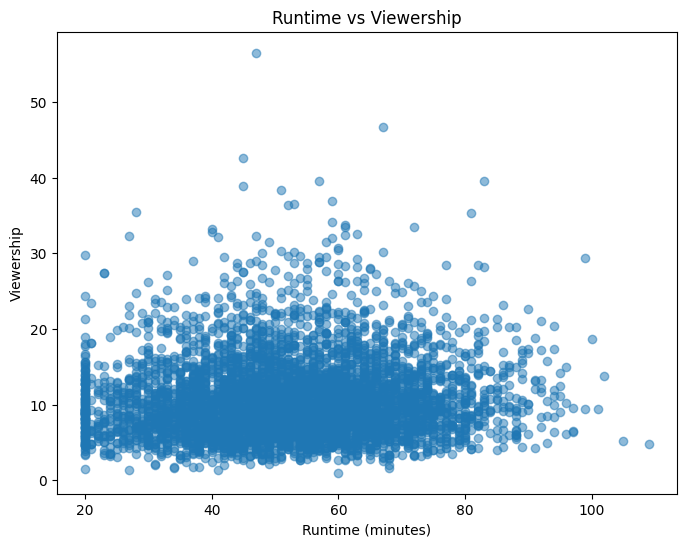

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(df["Runtime"], df["Viewership"], alpha=0.5)

plt.xlabel("Runtime (minutes)")
plt.ylabel("Viewership")
plt.title("Runtime vs Viewership")

plt.show()

In [33]:
year_analysis = df.groupby("Release_Year").agg(
    Number_of_Shows=("Show_ID", "count"),
    Average_Viewership=("Viewership", "mean"),
    Average_Rating=("Rating", "mean")
).round(2)

print(year_analysis)

              Number_of_Shows  Average_Viewership  Average_Rating
Release_Year                                                     
2018                      524                8.81            7.16
2019                      540                9.66            7.20
2020                      547               10.08            7.18
2021                      564               10.25            7.21
2022                      560               10.90            7.23
2023                      557               11.17            7.15
2024                      579               11.62            7.21
2025                      554               11.76            7.27
2026                      575               12.35            7.29


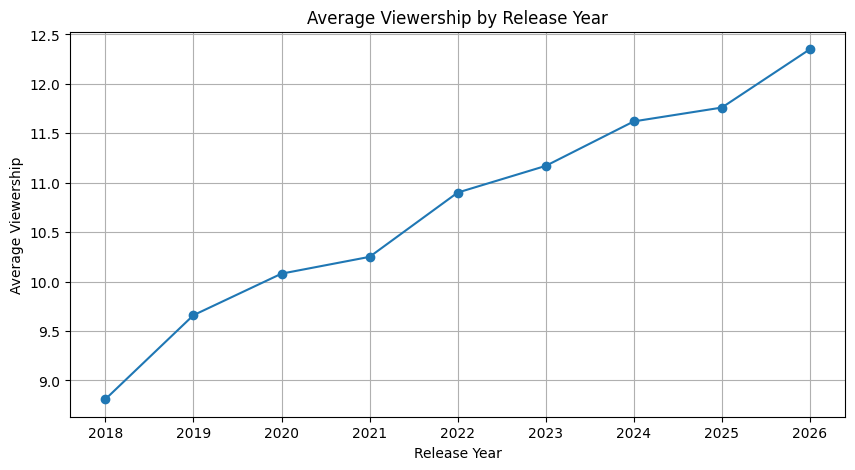

In [34]:
year_analysis["Average_Viewership"].plot(
    kind="line",
    marker="o",
    figsize=(10,5),
    title="Average Viewership by Release Year"
)

plt.xlabel("Release Year")
plt.ylabel("Average Viewership")
plt.grid(True)
plt.show()

In [35]:
threshold = df["Viewership"].median()

print("Success Threshold:", threshold)

Success Threshold: 9.82


In [37]:
df["Success"] = (df["Viewership"] >= threshold).astype(int)

df["Success_Label"] = df["Success"].map({
    0: "Less Successful",
    1: "Successful"
})
print(df["Success_Label"].value_counts())

Success_Label
Successful         2504
Less Successful    2496
Name: count, dtype: int64


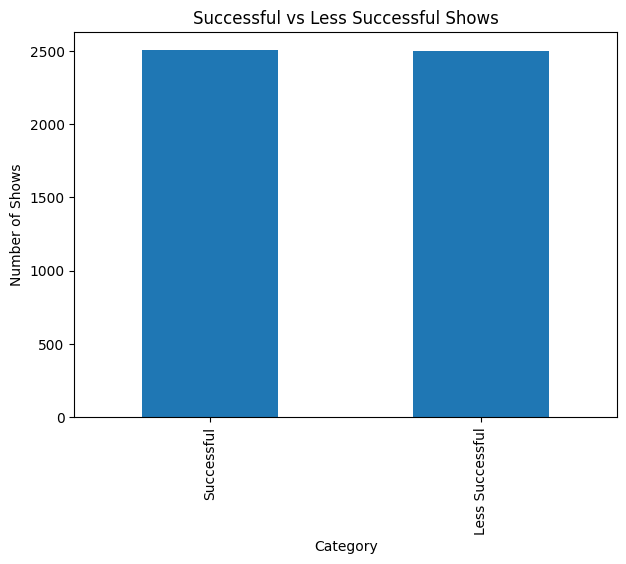

In [38]:
df["Success_Label"].value_counts().plot(
    kind="bar",
    figsize=(7,5),
    title="Successful vs Less Successful Shows"
)

plt.xlabel("Category")
plt.ylabel("Number of Shows")
plt.show()

In [39]:
success_analysis = df.groupby("Success_Label").agg(
    Average_Runtime=("Runtime", "mean"),
    Average_Budget=("Budget", "mean"),
    Average_Rating=("Rating", "mean"),
    Average_Viewership=("Viewership", "mean")
).round(2)

print(success_analysis)

                 Average_Runtime  Average_Budget  Average_Rating  \
Success_Label                                                      
Less Successful            51.42           16.49            6.93   
Successful                 53.68           26.40            7.49   

                 Average_Viewership  
Success_Label                        
Less Successful                6.96  
Successful                    14.54  


In [40]:
threshold = df["Viewership"].median()

print("Success threshold:", threshold)

df["Success"] = (df["Viewership"] >= threshold).astype(int)

df["Success_Label"] = df["Success"].map({
    0: "Less Successful",
    1: "Successful"
})

print(df["Success_Label"].value_counts())

Success threshold: 9.82
Success_Label
Successful         2504
Less Successful    2496
Name: count, dtype: int64


In [41]:
X = df[
    [
        "Genre",
        "Language",
        "Runtime",
        "Release_Year",
        "Budget",
        "Rating"
    ]
]

y = df["Success"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      Genre Language  Runtime  Release_Year  Budget  Rating
0     Drama    Hindi       36          2021     9.2     7.3
1  Thriller    Hindi       65          2022    12.6     7.9
2     Crime    Hindi       56          2019     4.0     5.9
3     Drama    Hindi       72          2021    53.9     6.3
4  Thriller   Korean       68          2020    17.3     8.6

Target:
0    0
1    0
2    0
3    1
4    0
Name: Success, dtype: int64


In [42]:
X = pd.get_dummies(
    X,
    columns=["Genre", "Language"],
    drop_first=True
)

print(X.head())
print(X.shape)

   Runtime  Release_Year  Budget  Rating  Genre_Comedy  Genre_Crime  \
0       36          2021     9.2     7.3         False        False   
1       65          2022    12.6     7.9         False        False   
2       56          2019     4.0     5.9         False         True   
3       72          2021    53.9     6.3         False        False   
4       68          2020    17.3     8.6         False        False   

   Genre_Documentary  Genre_Drama  Genre_Romance  Genre_Sci-Fi  \
0              False         True          False         False   
1              False        False          False         False   
2              False        False          False         False   
3              False         True          False         False   
4              False        False          False         False   

   Genre_Thriller  Language_Hindi  Language_Korean  Language_Malayalam  \
0           False            True            False               False   
1            True           

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 17)
Testing data: (1000, 17)


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [45]:
y_pred = rf_model.predict(X_test)

print(y_pred[:20])

[1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1]


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.712
Accuracy (%): 71.2 %


In [47]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Less Successful", "Successful"]
))

                 precision    recall  f1-score   support

Less Successful       0.71      0.71      0.71       499
     Successful       0.71      0.71      0.71       501

       accuracy                           0.71      1000
      macro avg       0.71      0.71      0.71      1000
   weighted avg       0.71      0.71      0.71      1000



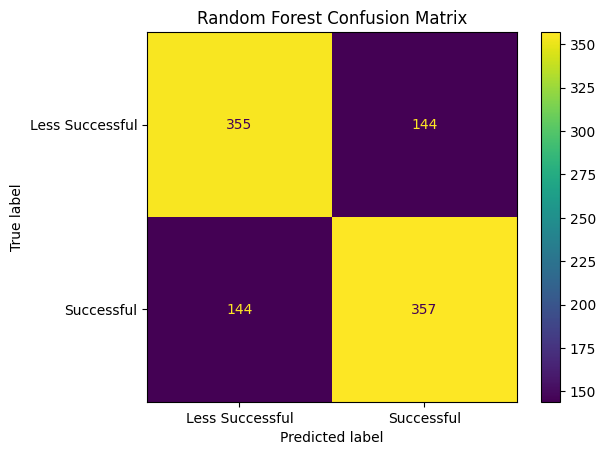

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Less Successful", "Successful"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
2               Budget    0.309831
3               Rating    0.219744
0              Runtime    0.163306
1         Release_Year    0.106463
6    Genre_Documentary    0.020358
11      Language_Hindi    0.018518
7          Genre_Drama    0.018510
4         Genre_Comedy    0.016811
15      Language_Tamil    0.016029
10      Genre_Thriller    0.015906
16     Language_Telugu    0.015065
12     Language_Korean    0.014377
8        Genre_Romance    0.014026
5          Genre_Crime    0.013684
13  Language_Malayalam    0.012600
14    Language_Spanish    0.012473
9         Genre_Sci-Fi    0.012300


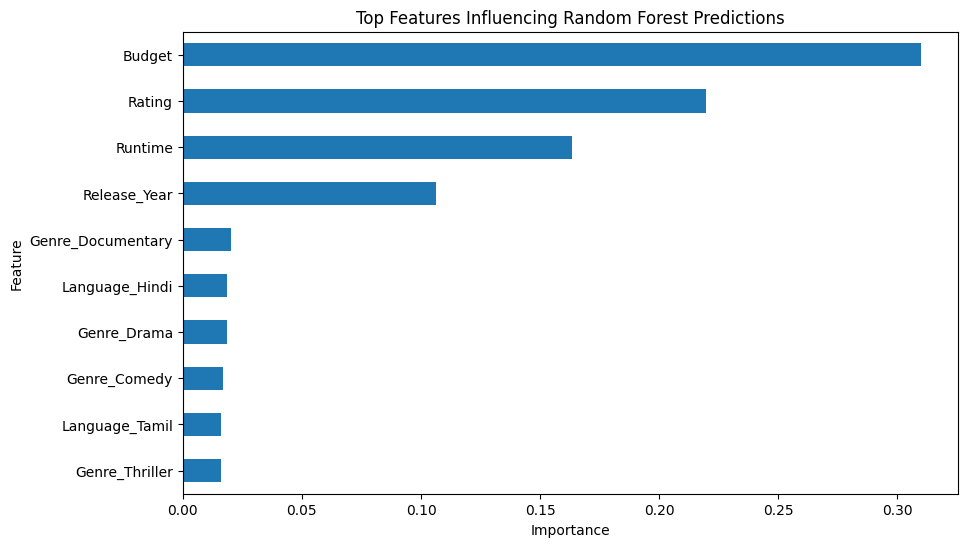

In [50]:
feature_importance.head(10).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6),
    legend=False,
    title="Top Features Influencing Random Forest Predictions"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [51]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Less Successful", "Successful"]
))

Random Forest Accuracy: 71.2 %

Classification Report:
                 precision    recall  f1-score   support

Less Successful       0.71      0.71      0.71       499
     Successful       0.71      0.71      0.71       501

       accuracy                           0.71      1000
      macro avg       0.71      0.71      0.71      1000
   weighted avg       0.71      0.71      0.71      1000



In [52]:
final_summary = df.groupby("Success_Label").agg(
    Shows=("Show_ID", "count"),
    Avg_Viewership=("Viewership", "mean"),
    Avg_Rating=("Rating", "mean"),
    Avg_Budget=("Budget", "mean"),
    Avg_Runtime=("Runtime", "mean")
).round(2)

print(final_summary)

                 Shows  Avg_Viewership  Avg_Rating  Avg_Budget  Avg_Runtime
Success_Label                                                              
Less Successful   2496            6.96        6.93       16.49        51.42
Successful        2504           14.54        7.49       26.40        53.68


In [53]:
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
              Feature  Importance
2              Budget    0.309831
3              Rating    0.219744
0             Runtime    0.163306
1        Release_Year    0.106463
6   Genre_Documentary    0.020358
11     Language_Hindi    0.018518
7         Genre_Drama    0.018510
4        Genre_Comedy    0.016811
15     Language_Tamil    0.016029
10     Genre_Thriller    0.015906
